In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

print("Libraries loaded successfully")

Libraries loaded successfully


In [3]:
df = pd.read_csv("../data/processed/olist_cleaned.csv")

# A customer is churned if they made only 1 purchase ever
customer_orders = df.groupby('customer_unique_id')['order_id'].nunique().reset_index()
customer_orders.columns = ['customer_unique_id', 'total_orders']
customer_orders['churned'] = (customer_orders['total_orders'] == 1).astype(int)

print("Churn distribution:")
print(customer_orders['churned'].value_counts())
print(f"\nChurn rate: {customer_orders['churned'].mean()*100:.1f}%")

Churn distribution:
churned
1    90557
0     2801
Name: count, dtype: int64

Churn rate: 97.0%


In [4]:
# Average order value per customer
customer_revenue = df.groupby('customer_unique_id')['price'].agg(['mean', 'sum']).reset_index()
customer_revenue.columns = ['customer_unique_id', 'avg_order_value', 'total_spent']

# Average delivery days per customer
customer_delivery = df.groupby('customer_unique_id')['delivery_days'].mean().reset_index()
customer_delivery.columns = ['customer_unique_id', 'avg_delivery_days']

# Average freight value per customer
customer_freight = df.groupby('customer_unique_id')['freight_value'].mean().reset_index()
customer_freight.columns = ['customer_unique_id', 'avg_freight']

# Payment installments
customer_installments = df.groupby('customer_unique_id')['payment_installments'].mean().reset_index()
customer_installments.columns = ['customer_unique_id', 'avg_installments']

# Merge all features
features = customer_orders.merge(customer_revenue, on='customer_unique_id')
features = features.merge(customer_delivery, on='customer_unique_id')
features = features.merge(customer_freight, on='customer_unique_id')
features = features.merge(customer_installments, on='customer_unique_id')

print("Features shape:", features.shape)
print(features.head())

Features shape: (93358, 8)
                 customer_unique_id  total_orders  churned  avg_order_value  \
0  0000366f3b9a7992bf8c76cfdf3221e2             1        1           129.90   
1  0000b849f77a49e4a4ce2b2a4ca5be3f             1        1            18.90   
2  0000f46a3911fa3c0805444483337064             1        1            69.00   
3  0000f6ccb0745a6a4b88665a16c9f078             1        1            25.99   
4  0004aac84e0df4da2b147fca70cf8255             1        1           180.00   

   total_spent  avg_delivery_days  avg_freight  avg_installments  
0       129.90                6.0        12.00               8.0  
1        18.90                3.0         8.29               1.0  
2        69.00               25.0        17.22               8.0  
3        25.99               20.0        17.63               4.0  
4       180.00               13.0        16.89               6.0  


In [5]:
X = features[['avg_order_value', 'total_spent', 'avg_delivery_days', 'avg_freight', 'avg_installments']]
y = features['churned']

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (74686, 5)
Test set size: (18672, 5)


In [6]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)
y_prob_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf)*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_rf):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results:
Accuracy: 97.24%
ROC-AUC Score: 0.9599

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.14      0.23       536
           1       0.98      1.00      0.99     18136

    accuracy                           0.97     18672
   macro avg       0.78      0.57      0.61     18672
weighted avg       0.96      0.97      0.96     18672



In [7]:
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob_lr):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results:
Accuracy: 87.95%
ROC-AUC Score: 0.9510

Classification Report:
              precision    recall  f1-score   support

           0       0.19      1.00      0.32       536
           1       1.00      0.88      0.93     18136

    accuracy                           0.88     18672
   macro avg       0.60      0.94      0.63     18672
weighted avg       0.98      0.88      0.92     18672



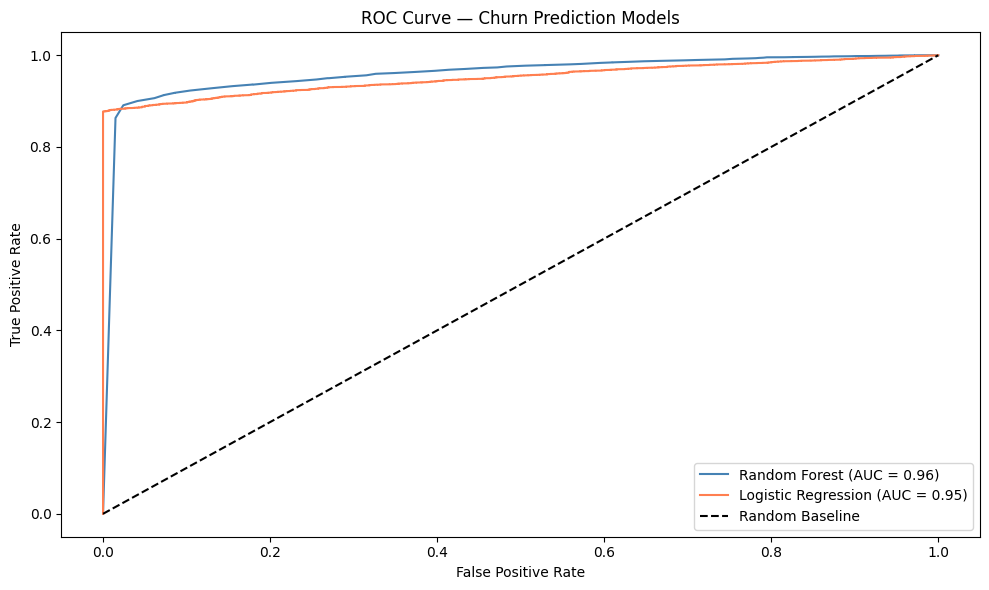

ROC curve saved


In [8]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = 0.96)', color='steelblue')
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = 0.95)', color='coral')
plt.plot([0, 1], [0, 1], 'k--', label='Random Baseline')
plt.title("ROC Curve — Churn Prediction Models")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("../reports/roc_curve.png")
plt.show()
print("ROC curve saved")

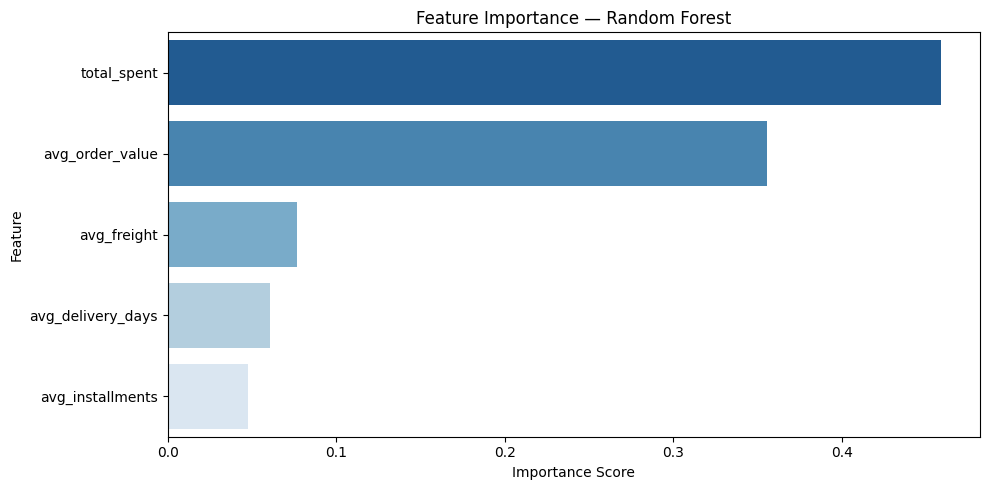

Feature Importance:
total_spent          0.459026
avg_order_value      0.355845
avg_freight          0.076786
avg_delivery_days    0.060800
avg_installments     0.047543
dtype: float64


In [9]:
feature_names = ['avg_order_value', 'total_spent', 'avg_delivery_days', 'avg_freight', 'avg_installments']
importance = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=importance.values, y=importance.index, hue=importance.index, palette='Blues_r', legend=False)
plt.title("Feature Importance — Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("../reports/feature_importance.png")
plt.show()

print("Feature Importance:")
print(importance)